# 04 Model Comparison

In [1]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_curve, auc, confusion_matrix
)
from sklearn.preprocessing import label_binarize
from ultralytics import YOLO

#uses MPS on apple silicon or CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
#paths
BASE_DIR    = Path("../")
TRAIN_DIR   = BASE_DIR / "data/statefarm_subject_split/train"
VAL_DIR     = BASE_DIR / "data/statefarm_subject_split/val"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR  = BASE_DIR / "models"
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

#YOLOv8n weights
YOLO_WEIGHTS = Path("runs/yolov8n_statefarm/weights/best.pt")
#training config 
NUM_CLASSES  = 10
EPOCHS       = 50 # running 50 epochs for all models 
BATCH_SIZE   = 32
IMG_SIZE     = 224
LR           = 0.001
SEED         = 42

torch.manual_seed(SEED)

#class names 
CLASS_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]
CLASS_DESC  = [
    "Safe Driving", "Texting (Right)", "Phone (Right)",
    "Texting (Left)", "Phone (Left)", "Radio",
    "Drinking", "Reaching Behind", "Hair/Makeup", "Talking to Passenger"
]

In [3]:
#ImageNet normalisation used by all torchvision pretrained models
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transforms)
val_dataset   = datasets.ImageFolder(str(VAL_DIR),   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)


In [4]:
def build_resnet18(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_mobilenet_v3(num_classes=10):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

def build_efficientnet_b0(num_classes=10):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

In [ ]:
def train_model(model, model_name, train_loader, val_loader,
                epochs=20, lr=0.001, device=device, patience=10):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0
    best_state = None
    epochs_no_improve = 0  #early stopping counter

    
    for epoch in range(epochs):
        #Training
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        #Validation
        model.eval()
        val_loss = 0.0
        correct  = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc   = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step()

        if val_acc > best_acc:
            best_acc          = val_acc
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc*100:.2f}% | "
              f"No improve: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"\n  Early stopping triggered at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

    # Restore best weights
    model.load_state_dict(best_state)

    # Save model
    save_path = MODELS_DIR / f"{model_name.lower().replace('-','_').replace(' ','_')}_best.pth"
    torch.save(best_state, save_path)
    return model, history, best_acc


def evaluate_model(model, val_loader, device=device):
    model.eval().to(device)
    y_true, y_pred, y_probs = [], [], []
    total_time = 0.0
    n_images   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            t0 = time.time()
            outputs = model(inputs)
            total_time += (time.time() - t0)
            n_images   += inputs.size(0)

            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_probs.extend(probs)

    inf_time_ms = (total_time / n_images) * 1000
    return (np.array(y_true), np.array(y_pred),
            np.array(y_probs), inf_time_ms)


def compute_metrics(y_true, y_pred, y_probs, model_name, inf_time_ms, model_size_mb):
    acc      = np.mean(y_true == y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    macro_p  = precision_score(y_true, y_pred, average="macro")
    macro_r  = recall_score(y_true, y_pred, average="macro")

    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        auc_scores.append(auc(fpr, tpr))
    mean_auc = np.mean(auc_scores)

    return {
        "Model":          model_name,
        "Top 1 Acc ":     round(acc * 100, 2),
        "Macro F1":       round(macro_f1, 4),
        "Macro Precision":round(macro_p, 4),
        "Macro Recall":   round(macro_r, 4),
        "Mean AUC":       round(mean_auc, 4),
        "Inf. Time (ms)": round(inf_time_ms, 2),
        "Size (MB)":      round(model_size_mb, 1),
    }, auc_scores


def get_model_size_mb(path):
    if Path(path).exists():
        return Path(path).stat().st_size / (1024 * 1024)
    return 0.0

In [8]:
resnet_model, resnet_history, resnet_best_acc = train_model(
    build_resnet18(), "ResNet18",
    train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device, patience=10
)


 Training ResNet18
  Epoch 01/50 | Train Loss: 0.2488 | Val Loss: 0.7704 | Val Acc: 78.81% | No improve: 0/10
  Epoch 02/50 | Train Loss: 0.0920 | Val Loss: 1.1268 | Val Acc: 70.83% | No improve: 1/10
  Epoch 03/50 | Train Loss: 0.0783 | Val Loss: 0.9845 | Val Acc: 75.92% | No improve: 2/10
  Epoch 04/50 | Train Loss: 0.0528 | Val Loss: 1.1189 | Val Acc: 73.84% | No improve: 3/10
  Epoch 05/50 | Train Loss: 0.0623 | Val Loss: 0.7654 | Val Acc: 80.47% | No improve: 0/10
  Epoch 06/50 | Train Loss: 0.0465 | Val Loss: 1.1541 | Val Acc: 73.76% | No improve: 1/10
  Epoch 07/50 | Train Loss: 0.0481 | Val Loss: 0.8211 | Val Acc: 79.20% | No improve: 2/10
  Epoch 08/50 | Train Loss: 0.0424 | Val Loss: 0.9340 | Val Acc: 77.95% | No improve: 3/10
  Epoch 09/50 | Train Loss: 0.0427 | Val Loss: 1.1071 | Val Acc: 75.66% | No improve: 4/10
  Epoch 10/50 | Train Loss: 0.0319 | Val Loss: 1.4635 | Val Acc: 65.63% | No improve: 5/10
  Epoch 11/50 | Train Loss: 0.0292 | Val Loss: 0.8149 | Val Acc: 80.92

In [7]:
mobilenet_model, mobilenet_history, mobilenet_best_acc = train_model(
    build_mobilenet_v3(), "MobileNetV3",
    train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device, patience=10
)


 Training MobileNetV3
  Epoch 01/50 | Train Loss: 0.2233 | Val Loss: 0.8865 | Val Acc: 77.20% | No improve: 0/10
  Epoch 02/50 | Train Loss: 0.0627 | Val Loss: 0.9476 | Val Acc: 80.53% | No improve: 0/10
  Epoch 03/50 | Train Loss: 0.0395 | Val Loss: 1.6346 | Val Acc: 72.33% | No improve: 1/10
  Epoch 04/50 | Train Loss: 0.0382 | Val Loss: 0.5888 | Val Acc: 85.47% | No improve: 0/10
  Epoch 05/50 | Train Loss: 0.0473 | Val Loss: 1.2926 | Val Acc: 67.55% | No improve: 1/10
  Epoch 06/50 | Train Loss: 0.0231 | Val Loss: 1.9154 | Val Acc: 65.60% | No improve: 2/10
  Epoch 07/50 | Train Loss: 0.0380 | Val Loss: 0.8769 | Val Acc: 80.01% | No improve: 3/10
  Epoch 08/50 | Train Loss: 0.0215 | Val Loss: 0.7020 | Val Acc: 81.25% | No improve: 4/10
  Epoch 09/50 | Train Loss: 0.0202 | Val Loss: 0.8761 | Val Acc: 79.36% | No improve: 5/10
  Epoch 10/50 | Train Loss: 0.0264 | Val Loss: 1.4777 | Val Acc: 72.26% | No improve: 6/10
  Epoch 11/50 | Train Loss: 0.0298 | Val Loss: 1.3436 | Val Acc: 70

In [8]:
efficientnet_model, efficientnet_history, efficientnet_best_acc = train_model(
    build_efficientnet_b0(), "EfficientNet-B0",
    train_loader, val_loader,
    epochs=EPOCHS, lr=LR, device=device, patience=10
)


 Training EfficientNet-B0
  Epoch 01/50 | Train Loss: 0.2374 | Val Loss: 0.4075 | Val Acc: 89.89% | No improve: 0/10
  Epoch 02/50 | Train Loss: 0.0685 | Val Loss: 0.6928 | Val Acc: 85.44% | No improve: 1/10
  Epoch 03/50 | Train Loss: 0.0585 | Val Loss: 0.5766 | Val Acc: 87.13% | No improve: 2/10
  Epoch 04/50 | Train Loss: 0.0430 | Val Loss: 0.6632 | Val Acc: 81.05% | No improve: 3/10
  Epoch 05/50 | Train Loss: 0.0390 | Val Loss: 0.9935 | Val Acc: 76.70% | No improve: 4/10
  Epoch 06/50 | Train Loss: 0.0389 | Val Loss: 0.5213 | Val Acc: 86.71% | No improve: 5/10
  Epoch 07/50 | Train Loss: 0.0424 | Val Loss: 0.5464 | Val Acc: 85.31% | No improve: 6/10
  Epoch 08/50 | Train Loss: 0.0289 | Val Loss: 0.6634 | Val Acc: 85.26% | No improve: 7/10
  Epoch 09/50 | Train Loss: 0.0298 | Val Loss: 0.3567 | Val Acc: 88.64% | No improve: 8/10
  Epoch 10/50 | Train Loss: 0.0303 | Val Loss: 0.7485 | Val Acc: 82.74% | No improve: 9/10
  Epoch 11/50 | Train Loss: 0.0209 | Val Loss: 0.7404 | Val Acc

In [6]:
#reload saved models
resnet_model = build_resnet18()
resnet_model.load_state_dict(torch.load(MODELS_DIR / "resnet18_best.pth", map_location=device))
resnet_model = resnet_model.to(device)

mobilenet_model = build_mobilenet_v3()
mobilenet_model.load_state_dict(torch.load(MODELS_DIR / "mobilenetv3_best.pth", map_location=device))
mobilenet_model = mobilenet_model.to(device)

efficientnet_model = build_efficientnet_b0()
efficientnet_model.load_state_dict(torch.load(MODELS_DIR / "efficientnet_b0_best.pth", map_location=device))
efficientnet_model = efficientnet_model.to(device)

In [ ]:
all_metrics = []
all_auc_scores = {}
all_histories = {}

for model, name in [
    (resnet_model,       "ResNet18"),
    (mobilenet_model,    "MobileNetV3"),
    (efficientnet_model, "EfficientNetB0"),
]:
    print(f"Evaluating {name}")
    y_true, y_pred, y_probs, inf_time = evaluate_model(model, val_loader, device)
    size_mb = get_model_size_mb(
        MODELS_DIR / f"{name.lower().replace('-','_').replace(' ','_')}_best.pth"
    )
    metrics, auc_scores = compute_metrics(y_true, y_pred, y_probs, name, inf_time, size_mb)
    all_metrics.append(metrics)
    all_auc_scores[name] = auc_scores

    print(f"  {name} — Acc: {metrics['Top 1 Acc ']:.2f}% | F1: {metrics['Macro F1']:.4f}")

Evaluating ResNet18
  ResNet18 — Acc: 84.22% | F1: 0.8391
Evaluating MobileNetV3
  MobileNetV3 — Acc: 85.47% | F1: 0.8558
Evaluating EfficientNet-B0
  EfficientNet-B0 — Acc: 89.89% | F1: 0.8949


In [14]:
all_metrics = [m for m in all_metrics if m.get("Model") != "YOLOv8n"]
print("evaluating YOLOv8n (baseline)")
yolo_model = YOLO(str(YOLO_WEIGHTS))

y_true_yolo, y_pred_yolo, y_probs_yolo = [], [], []
val_path = Path(VAL_DIR)
class_folders = sorted([d for d in val_path.iterdir() if d.is_dir()])

t_start = time.time()
n_imgs  = 0
for true_idx, folder in enumerate(class_folders):
    for img_path in folder.iterdir():
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        result   = yolo_model.predict(str(img_path), imgsz=224, verbose=False)[0]
        probs    = result.probs.data.cpu().numpy()
        pred_idx = int(np.argmax(probs))
        y_true_yolo.append(true_idx)
        y_pred_yolo.append(pred_idx)
        y_probs_yolo.append(probs)
        n_imgs += 1

yolo_inf_time = ((time.time() - t_start) / n_imgs) * 1000
yolo_size_mb  = get_model_size_mb(YOLO_WEIGHTS)

y_true_yolo  = np.array(y_true_yolo)
y_pred_yolo  = np.array(y_pred_yolo)
y_probs_yolo = np.array(y_probs_yolo)

yolo_metrics, yolo_auc = compute_metrics(
    y_true_yolo, y_pred_yolo, y_probs_yolo,
    "YOLOv8n", yolo_inf_time, yolo_size_mb
)
all_metrics.insert(0, yolo_metrics)
all_auc_scores["YOLOv8n"] = yolo_auc
print(f"   Acc: {yolo_metrics['Top 1 Acc ']:.2f}% | F1: {yolo_metrics['Macro F1']:.4f} | AUC: {yolo_metrics['Mean AUC']:.4f} | {yolo_inf_time:.2f}ms/img")

evaluating YOLOv8n (baseline)
   Acc: 92.30% | F1: 0.9220 | AUC: 0.9941 | 4.87ms/img


In [15]:
df_comparison = pd.DataFrame(all_metrics).set_index("Model")
print(df_comparison.to_string())
#save to CSV
df_comparison.to_csv(REPORTS_DIR / "model_comparison.csv")

                 Top 1 Acc   Macro F1  Macro Precision  Macro Recall  Mean AUC  Inf. Time (ms)  Size (MB)
Model                                                                                                    
YOLOv8n               92.30    0.9220           0.9243        0.9238    0.9941            4.87        2.8
ResNet18              84.22    0.8391           0.8436        0.8425    0.9762            0.08       42.7
MobileNetV3           85.47    0.8558           0.8678        0.8522    0.9796            0.24        5.9
EfficientNet-B0       89.89    0.8949           0.8996        0.8995    0.9868            0.36       15.6


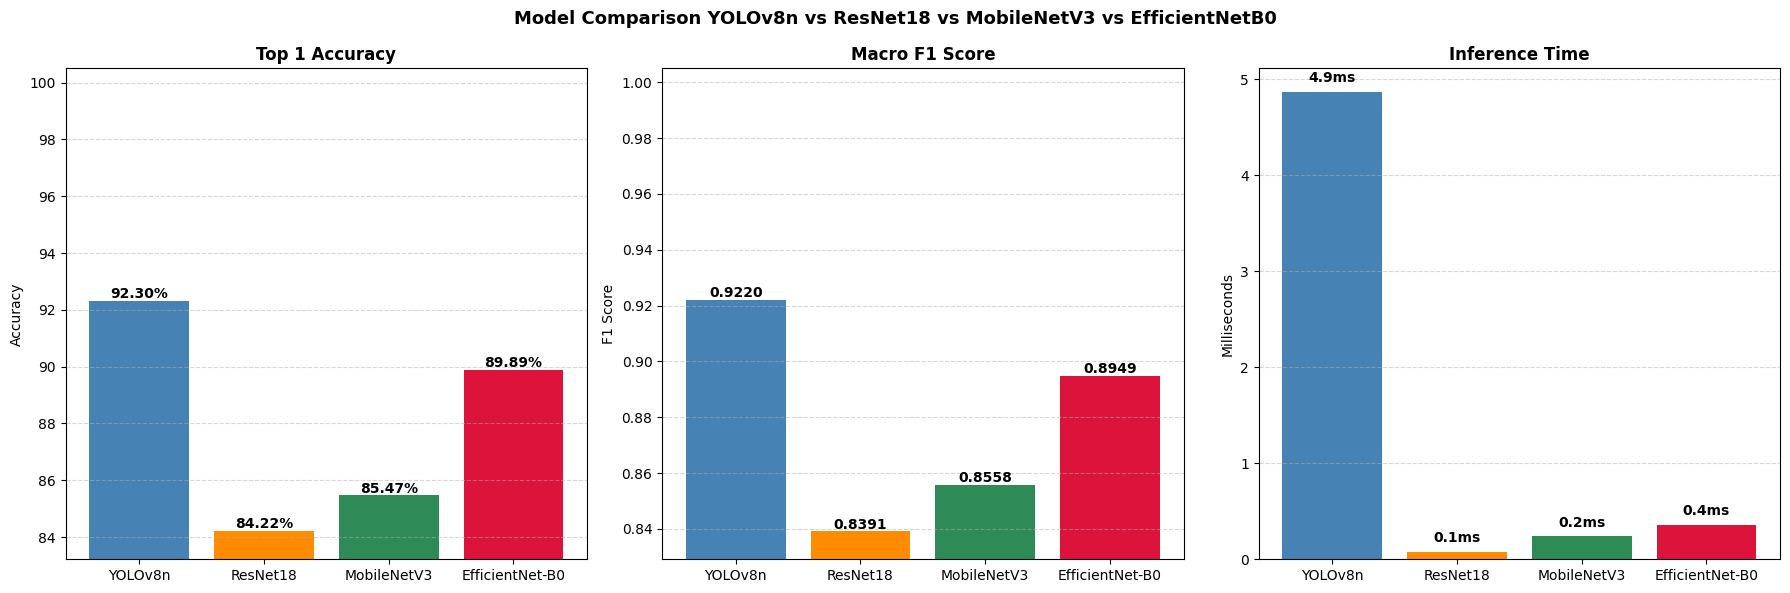

In [21]:
models_list = list(df_comparison.index)
colors = ["steelblue", "darkorange", "seagreen", "crimson"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Accuracy
axes[0].bar(models_list, df_comparison["Top 1 Acc "], color=colors)
axes[0].set_title("Top 1 Accuracy", fontweight="bold")
axes[0].set_ylim(df_comparison["Top 1 Acc "].min() - 1, 100.5)
axes[0].set_ylabel("Accuracy")
for i, v in enumerate(df_comparison["Top 1 Acc "]):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

#F1 score
axes[1].bar(models_list, df_comparison["Macro F1"], color=colors)
axes[1].set_title("Macro F1 Score", fontweight="bold")
axes[1].set_ylim(df_comparison["Macro F1"].min() - 0.01, 1.005)
axes[1].set_ylabel("F1 Score")
for i, v in enumerate(df_comparison["Macro F1"]):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

#Inference speed
axes[2].bar(models_list, df_comparison["Inf. Time (ms)"], color=colors)
axes[2].set_title("Inference Time", fontweight="bold")
axes[2].set_ylabel("Milliseconds")
for i, v in enumerate(df_comparison["Inf. Time (ms)"]):
    axes[2].text(i, v + 0.1, f"{v:.1f}ms", ha="center", fontsize=10, fontweight="bold")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Model Comparison YOLOv8n vs ResNet18 vs MobileNetV3 vs EfficientNetB0",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

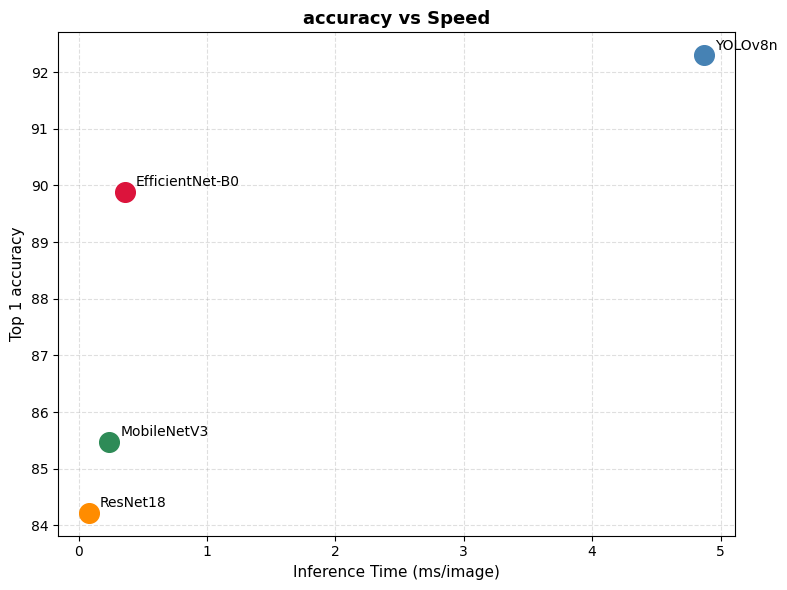

In [24]:

fig, ax = plt.subplots(figsize=(8, 6))

for i, model_name in enumerate(models_list):
    ax.scatter(
        df_comparison.loc[model_name, "Inf. Time (ms)"],
        df_comparison.loc[model_name, "Top 1 Acc "],
        s=200, color=colors[i], zorder=5, label=model_name
    )
    ax.annotate(
        model_name,
        (df_comparison.loc[model_name, "Inf. Time (ms)"],
         df_comparison.loc[model_name, "Top 1 Acc "]),
        textcoords="offset points", xytext=(8, 4), fontsize=10
    )

ax.set_xlabel("Inference Time (ms/image)", fontsize=11)
ax.set_ylabel("Top 1 accuracy", fontsize=11)
ax.set_title("accuracy vs Speed", fontweight="bold", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_accuracy_vs_speed.png", dpi=150, bbox_inches="tight")
plt.show()